© 2026 by Tamás Takács is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

# **Érzelemfrissítés (SOLUTION)**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI Nyári Diákolimpia, Tábor Válogató</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Natural Language Processing: Solution Notebook</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>40 pont</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2026. június</span>
  </div>
</div>

<br>

> **Figyelem:** ez a notebook a **szervezői/oktatási referencia** változat, NEM kerül ki a versenyzőkhöz. A cellák a teszthalmaz címkéit (`test_labeled.csv`, `a_gt.csv`) is használják, amelyek a versenyzői (RAW) notebookban **nem érhetők el**. A célja, hogy bemutassa a referencia megoldást, a **megadott** `Qwen/Qwen3-Embedding-4B` modell LoRA/DoRA adaptációját, és helyben reprodukálja a `f1_macro` pontozást.

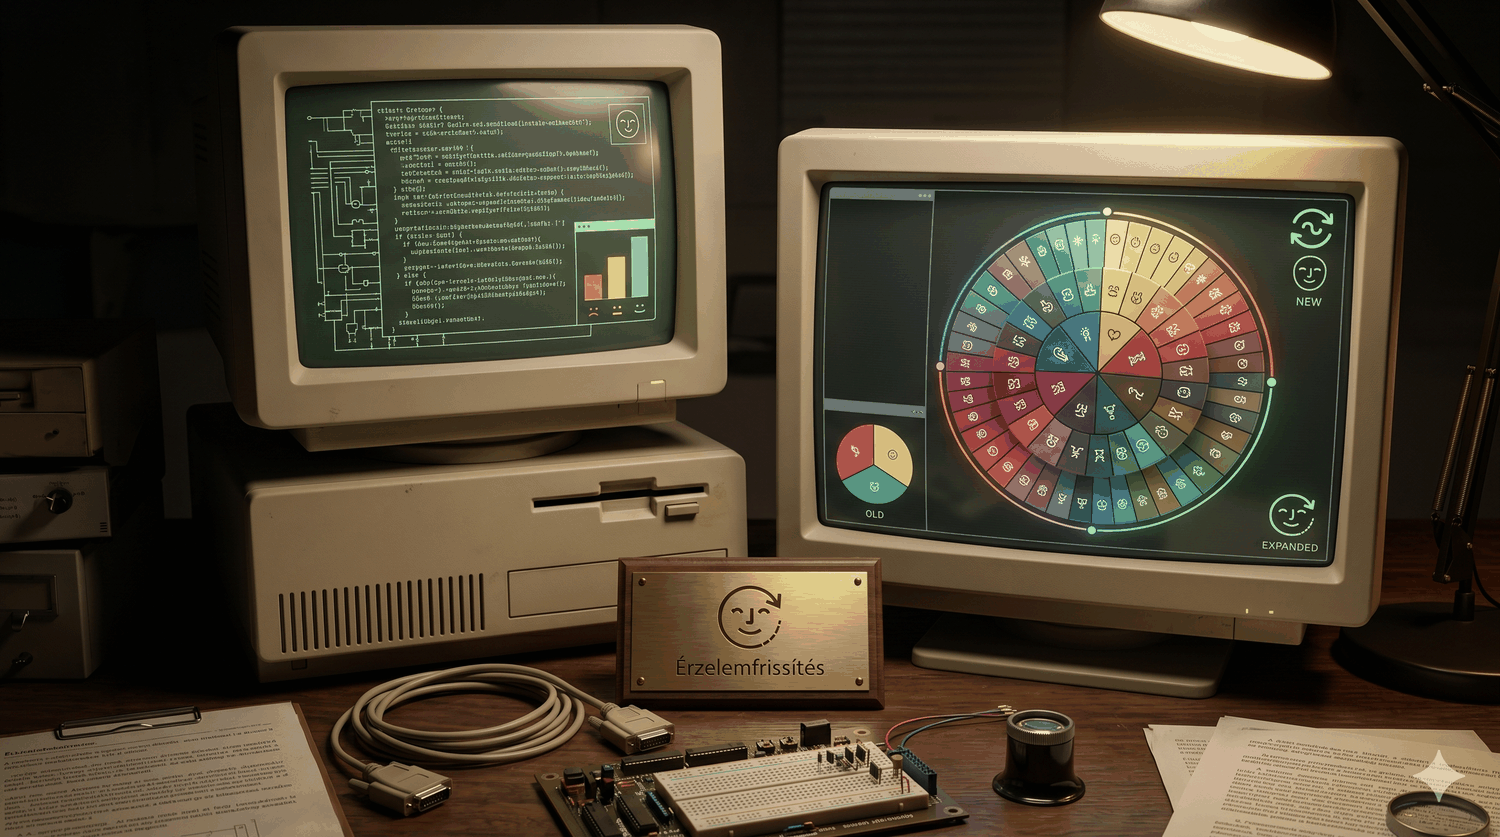

## **Beállítások és importok**

Rögzített random seed a reprodukálhatóságért.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Reprodukálhatóság: minden véletlent egyetlen seedhez kötünk.
# ═══════════════════════════════════════════════════════════════════
import os, random
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

## **Adathalmaz letöltése (privilegizált)**

A referencia a versenyzői fájlokon felül a címkézett tesztet, a ground truth-t és a publikus/privát szétválasztást is használja. A versenyzői fájlok (`train.csv`, `test_public.csv`) azonosítói ugyanazok, mint a RAW notebookban; a privilegizált fájlokat a szervező külön tölti fel, a `<...FILE_ID>` helyőrzőket ki kell tölteni.

| fájl | mit tartalmaz | versenyző látja? |
|------|---------------|:---:|
| `train.csv`        | címkézett tanítóhalmaz (`id,text,label`) | ✓ |
| `test_public.csv`  | teszt-bemenet (`id,text`)                | ✓ |
| `test_labeled.csv` | a teszt címkékkel (`id,text,target`)     | ✗ |
| `a_gt.csv`         | privát ground truth (`id,target`)        | ✗ |
| `public_ids.csv`   | a publikus részhalmaz id-jai             | ✗ |

In [ ]:
import os, subprocess, sys

FILES = {
    "train.csv":        "1iQM-H-s4a7EWSLjqT8lw_Sf99o3jJ8aZ",   # versenyzői
    "test_public.csv":  "1tX5mY-Pv8HKPmZr9lm8y-ucnwOpZU453",   # versenyzői
    "test_labeled.csv": "18rzwBGGs4UIdzZmgWiYx366Bs99u5lgF",   # privilegizált
    "a_gt.csv":         "1wGf7XJqIKJYzLgxtHq0yyynBlvzH03yy",            # privilegizált
    "public_ids.csv":   "1I8Wi393R82XApqbmpx65EUmkcfMNCqZj",      # privilegizált
}
missing = [name for name in FILES if not os.path.exists(name)]
if not missing:
    print("Minden fájl megvan a munkamappában, letöltés kihagyva.")
else:
    try:
        import gdown  # type: ignore
    except ImportError:
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown  # type: ignore
        except Exception:
            gdown = None  # type: ignore
    if gdown is None:
        print("gdown nem elérhető. Töltsd le kézzel a munkamappába:\n")
        for name in missing:
            print(f"  https://drive.google.com/uc?id={FILES[name]}  ->  {name}")
    else:
        for name in missing:
            try:
                gdown.download(id=FILES[name], output=name, quiet=False)
            except Exception as e:
                print(f"  {name} letöltése sikertelen: {e}")

## **Adatok betöltése**

In [ ]:
train_df     = pd.read_csv("train.csv")        # id, text, label (0..4)
test_df      = pd.read_csv("test_public.csv")  # id, text
test_labeled = pd.read_csv("test_labeled.csv") # id, text, target  (privilegizált)
print("train:", len(train_df), "| test:", len(test_df))

## **Az adatok feltárása**

Mielőtt modellt építünk, érdemes megnézni az adatot: kiegyensúlyozott-e az osztályeloszlás, milyen hosszúak a szövegek, és hogyan néznek ki a nehéz, köztes esetek.

In [ ]:
print("Osztályeloszlás (train):")
print(train_df["label"].value_counts().sort_index().to_string())

train_df["nwords"] = train_df["text"].str.split().str.len()
print("\nÁtlagos szóhossz osztályonként:")
print(train_df.groupby("label")["nwords"].mean().round(1).to_string())

print("\nPélda a köztes (2 = semleges/vegyes) osztályból:")
for t in train_df[train_df["label"] == 2]["text"].head(2):
    print(" -", t[:150], "...")

**Megfigyelés.** Az osztályok kiegyensúlyozottak, így nincs olcsó többségi trükk, és a szóhossz sem árulkodik a címkéről. A szélső osztályok (0 és 4) erős, egyértelmű jeleket hordoznak; a 2-es (semleges/vegyes) és a szomszédos 1/3 viszont valódi szövegértést kíván, ugyanaz a szó pozitív és negatív kontextusban is előfordul. A pontszámot ezeknek a köztes eseteknek a feloldása dönti el.

## **A pontozás reprodukciója**

A szerver (`evaluate-submission/index.ts`, `ef_f1` ág) a beadott `(id,target)` CSV-ből **makró-átlagolt F1**-et számol (az öt osztály F1-értékének számtani közepe), majd egy **floor/ceiling görbét** tesz rá: a nyers F1 **0.85 alatt 0**, **0.965 felett a teljes** (100), közte lineáris. Erre azért van szükség, mert a nyers F1 ezen a feladaton tömör (bármely értelmes modell kb. 0.84 és 0.96 közé esik), így a lineáris skála alig terítené szét a mezőnyt. A 0..100 értéket a DOCK a `max_score`-ral (40 pont) skálázza a megjelenítéshez.

In [ ]:
def score_submission(sub_csv, gt_csv="a_gt.csv", public_ids_csv="public_ids.csv"):
    """A DOCK `ef_f1` reprodukciója: makró-átlagolt F1, floor/ceiling görbével
    (0.85 nyers -> 0, 0.965 nyers -> 100, közte lineáris), publikus/privát bontással."""
    EF_FLOOR, EF_CEIL = 0.85, 0.965
    def ef_curve(raw):
        if raw <= EF_FLOOR: return 0.0
        if raw >= EF_CEIL:  return 100.0
        return (raw - EF_FLOOR) / (EF_CEIL - EF_FLOOR) * 100
    sub = pd.read_csv(sub_csv).set_index("id")["target"]
    gt  = pd.read_csv(gt_csv).set_index("id")["target"]
    pub = set(pd.read_csv(public_ids_csv)["id"])
    def mf1(ids):
        ids = [i for i in gt.index if i in ids]
        raw = f1_score(gt.loc[ids], sub.loc[ids], average="macro", labels=[0, 1, 2, 3, 4])
        return round(ef_curve(raw), 2)
    return mf1(pub), mf1(set(gt.index) - pub)

# Ellenőrzés: a tökéletes beadás (a_gt önmaga ellen) a teljes pontot éri (raw 1.0 -> 100).
print("tökéletes beadás -> public, private =", score_submission("a_gt.csv"))

## **Kalibrációs alap (nem megoldás)**

A pontozási skála aljának kalibrálásához nézzük meg, mit ér egy triviális, konstans jóslat: minden tesztsorra a leggyakoribb tanító-címkét adjuk. Ez **nem megoldás**, csak referencia, megmutatja, honnan indulunk, és hogy a `f1_macro` mennyire bünteti, ha csak egy osztályt találunk el.

In [ ]:
maj = int(train_df["label"].mode()[0])
pd.DataFrame({"id": test_df["id"], "target": maj}).to_csv("baseline.csv", index=False)
print(f"konstans (mindig {maj}) -> public, private =", score_submission("baseline.csv"), "  # a görbe alja")

## **A megoldás: Qwen3-Embedding-4B + LoRA/DoRA**

A megadott `Qwen/Qwen3-Embedding-4B` egy nagy (4B paraméteres) embedding modell, ami teljes finomhangolással nem fér be egy GPU-ba. A referencia ezért **paraméter-hatékonyan** adaptálja:

- **Backbone-vágás (`cut_layers_train`):** a felső rétegek levágása csökkenti a memóriát és a tanítási időt, miközben az alsó rétegek erős, általános szövegreprezentációja megmarad.
- **4-bites kvantálás (`bitsandbytes`):** a backbone-t kvantáltan töltjük be, így ~16–24 GB VRAM elég.
- **LoRA/DoRA adapter + lineáris osztályozófej:** csak az adaptert és a fejet tanítjuk; a backbone fagyott marad.
- **Osztály-súlyozott keresztentrópia + korai megállás:** a köztes osztályokra is figyelünk, és kerüljük a túltanulást.

A teljes, letesztelt pipeline a `scripts/train_model.py`-ban van; itt meghívjuk (a munkamappába letöltött fájlokra állítva), majd a legjobb adapterrel előállítjuk a beadást.

> **GPU szükséges** (4-bites kvantáláshoz `bitsandbytes`; a LoRA úthoz ~16–24 GB VRAM elég).

In [ ]:
import sys; sys.path.insert(0, "scripts")
import torch, pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, DataCollatorWithPadding
from peft import LoraConfig, get_peft_model, set_peft_model_state_dict, prepare_model_for_kbit_training
import train_model as T

# 1) Tanítás a munkamappába letöltött fájlokon. Menti: run_001_best_adapter.pt
cfg = T.merge_with_defaults({"run_name": "run_001", "epochs": 20,
                             "backbone_mode": "cut_layers_train", "n_layers_to_cut_from_end": 14,
                             "use_lora": True, "use_dora": True, "lora_r": 8, "lora_alpha": 16,
                             "quantization_mode": "4bit",
                             "train_csv": "train.csv", "test_csv": "test_labeled.csv"})
T.run_training(cfg)

# 2) A legjobb adapter visszatöltése és a test_public predikciója -> submission.csv
def make_qwen_submission(adapter_path="run_001_best_adapter.pt",
                         test_csv="test_public.csv", out="submission.csv"):
    device = T.resolve_device("auto"); qcfg = T.build_quantization_config("4bit")
    tok = AutoTokenizer.from_pretrained(T.DEFAULT_CONFIG["model_name"], trust_remote_code=True, padding_side="left")
    if tok.pad_token is None: tok.pad_token = tok.eos_token or tok.unk_token
    m = T.CustomQwenEmbeddingClassifier(T.DEFAULT_CONFIG["model_name"], num_labels=5,
                                        device=device, quantization_config=qcfg)
    m.backbone.config.pad_token_id = tok.pad_token_id
    m.configure_backbone("cut_layers_train", n_layers_to_cut_from_end=14)
    m = prepare_model_for_kbit_training(m)
    m = get_peft_model(m, LoraConfig(r=8, lora_alpha=16, target_modules="all-linear",
                                     use_dora=True, lora_dropout=0.05, bias="none", task_type="SEQ_CLS"))
    set_peft_model_state_dict(m, torch.load(adapter_path, map_location="cpu"))
    df = pd.read_csv(test_csv); coll = DataCollatorWithPadding(tokenizer=tok, padding=True)
    loader = DataLoader(T.SentimentDataset(df.assign(label=0), tok, 256,
                        T.DEFAULT_CONFIG["embedding_instruction"]),
                        batch_size=16, shuffle=False, collate_fn=coll)
    m.eval(); preds = []
    with torch.no_grad():
        for b in loader:
            o = m(input_ids=b["input_ids"].to(m.device), attention_mask=b["attention_mask"].to(m.device))
            preds += o["logits"].argmax(-1).cpu().tolist()
    pd.DataFrame({"id": df["id"], "target": [int(p) for p in preds]}).to_csv(out, index=False)
    print("wrote", out)

make_qwen_submission()

## **Eredmény: a beadás pontozása**

A `submission.csv`-t a privát GT-vel pontozzuk, pontosan ezt teszi a DOCK szerveroldalon.

In [ ]:
print("Qwen + LoRA/DoRA -> public, private =", score_submission("submission.csv"))

## **Hibaanalízis**

Érdemes a `submission.csv`-t a `test_labeled.csv` címkéivel összevetni (osztályonkénti F1, tévesztési mátrix). A tipikus mintázat: a 0 és 4 osztályt a modell magabiztosan eltalálja, a hibák pedig szinte mindig **egy szomszédos osztályra** esnek (1↔2, 3↔4), vagyis a modell a polaritást érti, a finom intenzitást nem mindig. A `hangolható elemek` közül a `lora_r`/`lora_alpha` emelése és a `use_dora` általában éppen ezeken a köztes osztályokon segít a legtöbbet, míg a túl agresszív backbone-vágás itt ront.

## **Hangolható elemek (mind a rögzített Qwen modellen belül)**

| Elem | Mit állít | Tipp |
|------|-----------|------|
| `backbone_mode` | `classifier_only` (fagyott backbone + fej) vs `cut_layers_train` (levágott rétegek + LoRA) | a `cut_layers_train` adja a legjobb minőség/költség arányt |
| `n_layers_to_cut_from_end` | hány réteget vágunk le a végéről | több vágás = gyorsabb/kisebb, de gyengébb |
| `lora_r`, `lora_alpha` | a LoRA adapter kapacitása | r = 8–16 jó kiindulás |
| `use_dora` | DoRA (súly-dekompozíció) be/ki | gyakran +néhány tized a köztes osztályokon |
| `quantization_mode` | `4bit` / `8bit` / `none` | `4bit` a VRAM-hoz; `none` csak nagy GPU-n |

Mindezek a **megadott** `Qwen/Qwen3-Embedding-4B` modellt adaptálják, más modellre cserélni (transformer vagy klasszikus baseline) **nem** megengedett.

## **Megjegyzések**

- A DOCK kizárólag a `submission.csv`-t pontozza `f1_macro`-val; a tanítás sebessége és a modell mérete NEM számít. (A `scripts/train_model.py` egy régi MES riportot is ír, ezt a DOCK figyelmen kívül hagyja.)
- A „megadott modellt kell használni" megkötést a DOCK nem tudja ellenőrizni (csak a predikciókat látja); a beadott notebook utólagos auditja az alapja.
- A `score_submission` a `grader/scoring.py` inline reprodukciója; a kalibráció a `tests/test_suboptimal.py`-ban van leellenőrizve.